In [252]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from sklearn.cluster import KMeans
from sklearn import preprocessing
import matplotlib.pyplot as pl
import seaborn as sns

#source: https://stackoverflow.com/questions/33458834/k-means-clustering-in-python
#source: https://stackoverflow.com/questions/57986346/how-to-do-clustering-with-k-means-algorithm-for-an-imported-data-set-with-proper
#genAI used in debugging and where directly cited

In [253]:
project_location = Path.cwd()
data_location = Path.cwd().parent/"data"/"additional"
print(project_location)

/Users/oliviawesel/Desktop/soccer-analytics-capstone-template/analysis


In [254]:
# path = project_location/ 'all_k_means.csv'
df = pd.read_parquet(data_location/'all_k_means.parquet')
print(df.head())

   player_id MEN_WOMEN  pct_shot_first_time  pct_shot_follows_dribble  \
0       3043         M             0.223022                       0.0   
1       3570         M             0.347826                       0.0   
2       3959         M             0.310345                       0.0   
3       8621         M             0.400000                       0.0   
4      21261         M             0.555556                       0.0   

   pct_shot_open_goal  pct_shot_dominant_foot  pct_shot_header  \
0            0.000000                0.762590         0.000000   
1            0.000000                0.891304         0.065217   
2            0.068966                0.379310         0.551724   
3            0.000000                0.800000         0.000000   
4            0.000000                0.555556         0.222222   

   pct_shot_goal_scored  pct_shot_taken_saved  shots_per_minute  ...  \
0              0.064748              0.007194          0.032483  ...   
1              0.000

In [255]:
df.isnull().sum()
print(len(df))

9035


In [256]:
df.dropna(inplace=True)
print(len(df))

4840


In [257]:
df = df.drop(columns=['player_id'])

### Split Men's League and Women's League

In [258]:
df_m = df[df['MEN_WOMEN'] == 'M']
df_m = df.drop(columns=['MEN_WOMEN'])
df_w = df[df['MEN_WOMEN'] == 'W']
df_w = df.drop(columns=['MEN_WOMEN'])

### Men's League

In [259]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df_m)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df_m.columns)
df_numeric_scaled.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,pass_attempts_per_minute,percent_cross_success,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute
0,0.223022,0.0,0.000000,0.762590,0.000000,0.064748,0.007194,0.135087,0.058686,0.028777,...,0.215080,0.262136,0.407407,0.070654,0.134766,0.307850,0.408224,0.398355,0.350467,0.282148
1,0.347826,0.0,0.000000,0.891304,0.065217,0.000000,0.021739,0.083167,0.037121,0.130435,...,0.251203,0.200000,0.333333,0.012076,0.030190,0.315699,0.448687,0.410351,0.313604,0.064525
2,0.310345,0.0,0.068966,0.379310,0.551724,0.241379,0.034483,0.072305,0.064208,0.655172,...,0.208688,1.000000,0.000000,0.010432,0.001304,0.287817,0.484054,0.507899,0.247898,0.004144
3,0.400000,0.0,0.000000,0.800000,0.000000,0.200000,0.000000,0.056589,0.058598,0.000000,...,0.302432,1.000000,0.000000,0.000000,0.014894,0.510638,0.587801,0.388085,0.109422,0.167071
4,0.555556,0.0,0.000000,0.555556,0.222222,0.000000,0.000000,0.130338,0.045627,0.333333,...,0.068196,0.600000,0.666667,0.165354,0.137795,0.472441,0.455643,0.314961,0.261530,0.217872


In [260]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

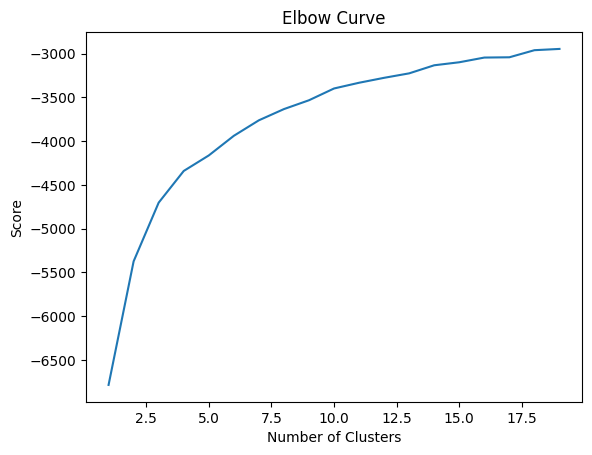

In [261]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [262]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(df_numeric_scaled)
df_m['cluster'] = kmeans.labels_
df_m.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,percent_cross_success,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute,cluster
0,0.223022,0.0,0.000000,0.762590,0.000000,0.064748,0.007194,0.032483,0.870850,0.028777,...,0.262136,0.407407,0.010093,0.038505,0.205234,0.218692,0.248972,0.327103,0.029533,3
1,0.347826,0.0,0.000000,0.891304,0.065217,0.000000,0.021739,0.022565,-2.706043,0.130435,...,0.200000,0.333333,0.001725,0.008626,0.210466,0.240368,0.256469,0.292697,0.006754,3
2,0.310345,0.0,0.068966,0.379310,0.551724,0.241379,0.034483,0.020490,1.786721,0.655172,...,1.000000,0.000000,0.001490,0.000373,0.191878,0.259314,0.317437,0.231371,0.000434,1
3,0.400000,0.0,0.000000,0.800000,0.000000,0.200000,0.000000,0.017488,0.856207,0.000000,...,1.000000,0.000000,0.000000,0.004255,0.340426,0.314894,0.242553,0.102128,0.017488,3
4,0.555556,0.0,0.000000,0.555556,0.222222,0.000000,0.000000,0.031576,-1.295278,0.333333,...,0.600000,0.666667,0.023622,0.039370,0.314961,0.244094,0.196850,0.244094,0.022805,0


In [263]:
len(df_m.columns)

45

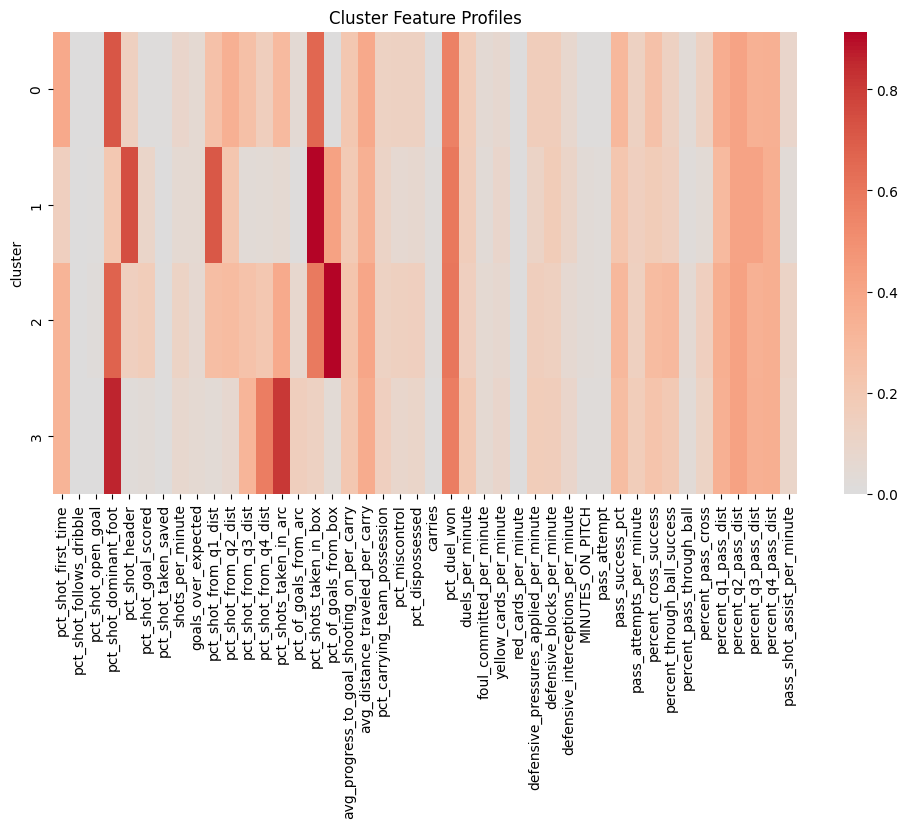

In [264]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df_m['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

### Women's League

In [265]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df_w)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df_w.columns)
df_numeric_scaled.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,pass_attempts_per_minute,percent_cross_success,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute
0,0.223022,0.0,0.000000,0.762590,0.000000,0.064748,0.007194,0.135087,0.058686,0.028777,...,0.215080,0.262136,0.407407,0.070654,0.134766,0.307850,0.408224,0.398355,0.350467,0.282148
1,0.347826,0.0,0.000000,0.891304,0.065217,0.000000,0.021739,0.083167,0.037121,0.130435,...,0.251203,0.200000,0.333333,0.012076,0.030190,0.315699,0.448687,0.410351,0.313604,0.064525
2,0.310345,0.0,0.068966,0.379310,0.551724,0.241379,0.034483,0.072305,0.064208,0.655172,...,0.208688,1.000000,0.000000,0.010432,0.001304,0.287817,0.484054,0.507899,0.247898,0.004144
3,0.400000,0.0,0.000000,0.800000,0.000000,0.200000,0.000000,0.056589,0.058598,0.000000,...,0.302432,1.000000,0.000000,0.000000,0.014894,0.510638,0.587801,0.388085,0.109422,0.167071
4,0.555556,0.0,0.000000,0.555556,0.222222,0.000000,0.000000,0.130338,0.045627,0.333333,...,0.068196,0.600000,0.666667,0.165354,0.137795,0.472441,0.455643,0.314961,0.261530,0.217872


In [266]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

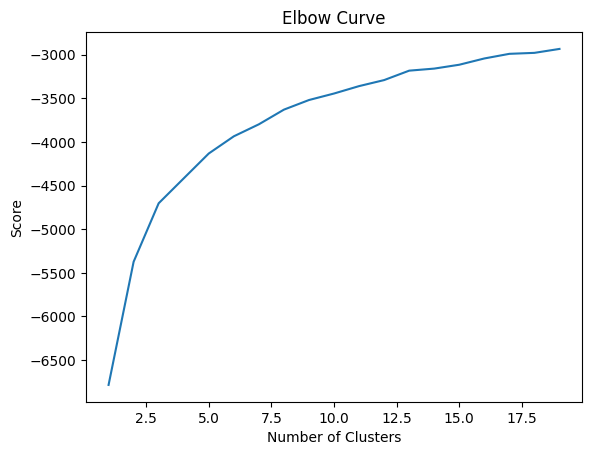

In [267]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [268]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(df_numeric_scaled)
df_w['cluster'] = kmeans.labels_
df_w.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_goal_scored,pct_shot_taken_saved,shots_per_minute,goals_over_expected,pct_shot_from_q1_dist,...,percent_cross_success,percent_through_ball_success,percent_pass_through_ball,percent_pass_cross,percent_q1_pass_dist,percent_q2_pass_dist,percent_q3_pass_dist,percent_q4_pass_dist,pass_shot_assist_per_minute,cluster
0,0.223022,0.0,0.000000,0.762590,0.000000,0.064748,0.007194,0.032483,0.870850,0.028777,...,0.262136,0.407407,0.010093,0.038505,0.205234,0.218692,0.248972,0.327103,0.029533,2
1,0.347826,0.0,0.000000,0.891304,0.065217,0.000000,0.021739,0.022565,-2.706043,0.130435,...,0.200000,0.333333,0.001725,0.008626,0.210466,0.240368,0.256469,0.292697,0.006754,0
2,0.310345,0.0,0.068966,0.379310,0.551724,0.241379,0.034483,0.020490,1.786721,0.655172,...,1.000000,0.000000,0.001490,0.000373,0.191878,0.259314,0.317437,0.231371,0.000434,1
3,0.400000,0.0,0.000000,0.800000,0.000000,0.200000,0.000000,0.017488,0.856207,0.000000,...,1.000000,0.000000,0.000000,0.004255,0.340426,0.314894,0.242553,0.102128,0.017488,2
4,0.555556,0.0,0.000000,0.555556,0.222222,0.000000,0.000000,0.031576,-1.295278,0.333333,...,0.600000,0.666667,0.023622,0.039370,0.314961,0.244094,0.196850,0.244094,0.022805,3


In [269]:
len(df_w.columns)

45

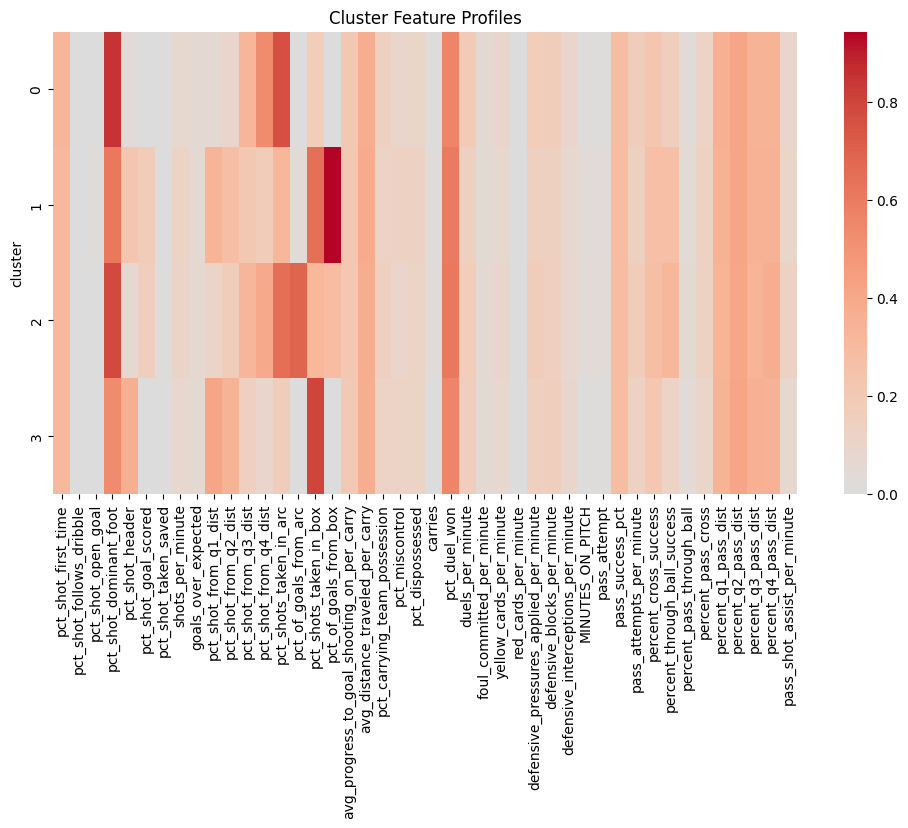

In [270]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df_w['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

## Carry K-Means

In [271]:
df = pd.read_parquet(data_location/'carry_k_means.parquet')
print(df.head())

   player_id  avg_progress_to_goal_shooting_on_per_carry  \
0      11746                                    1.014954   
1       3477                                    2.682264   
2       3874                                    1.544288   
3       3629                                    3.896256   
4      10499                                    3.279143   

   avg_distance_traveled_per_carry  pct_carrying_team_possession  \
0                         4.399259                      0.042749   
1                         7.050323                      0.026689   
2                         5.080311                      0.044520   
3                         8.452967                      0.061305   
4                         7.355203                      0.038172   

   pct_miscontrol  pct_dispossessed  carries  
0        0.021505          0.053763     93.0  
1        0.106855          0.087702    992.0  
2        0.018397          0.029566   1522.0  
3        0.074249          0.058928   1697

In [272]:
df.isnull().sum()
print(len(df))

8986


In [273]:
df.dropna(inplace=True)
print(len(df))

5698


In [274]:
df = df.drop(columns=['player_id'])

In [275]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,avg_progress_to_goal_shooting_on_per_carry,avg_distance_traveled_per_carry,pct_carrying_team_possession,pct_miscontrol,pct_dispossessed,carries
0,0.092036,0.237918,0.126973,0.043011,0.143369,0.002285
1,0.243227,0.462079,0.075298,0.213710,0.233871,0.025633
2,0.140035,0.295504,0.132675,0.036794,0.078844,0.039397
3,0.353311,0.580680,0.186683,0.148497,0.157140,0.043942
4,0.297352,0.487859,0.112247,0.114695,0.114695,0.007116


In [276]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

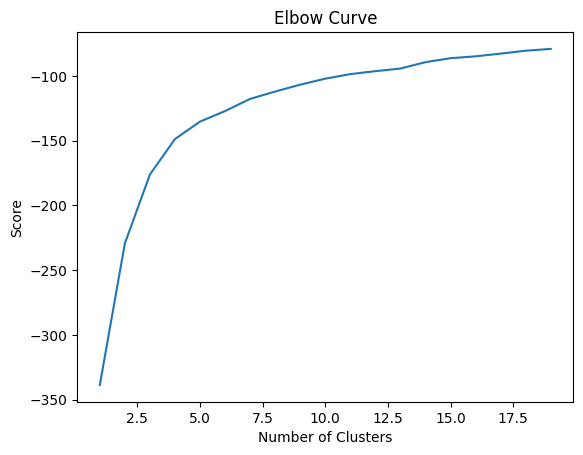

In [277]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [278]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
df.head()

,avg_progress_to_goal_shooting_on_per_carry,avg_distance_traveled_per_carry,pct_carrying_team_possession,pct_miscontrol,pct_dispossessed,carries,cluster
0,1.014954,4.399259,0.042749,0.021505,0.053763,93.0,3
1,2.682264,7.050323,0.026689,0.106855,0.087702,992.0,2
2,1.544288,5.080311,0.044520,0.018397,0.029566,1522.0,3
3,3.896256,8.452967,0.061305,0.074249,0.058928,1697.0,0
4,3.279143,7.355203,0.038172,0.057348,0.043011,279.0,4


In [279]:
len(df.columns)

7

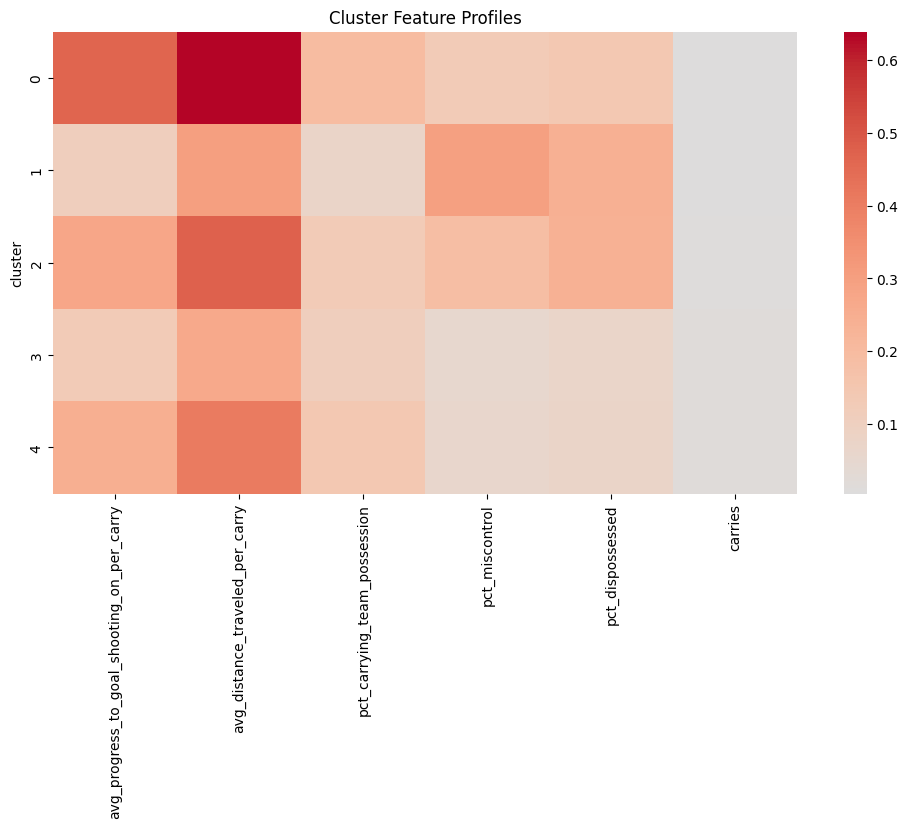

In [280]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

## Defense K-Means

In [281]:
df = pd.read_parquet(data_location/'defense_k_means.parquet')
print(df.head())

   player_id  pct_duel_won  duels_per_minute  foul_committed_per_minute  \
0      18149      0.673077          0.034443                   0.000000   
1      18253      0.571429          0.018007                   0.000857   
2       3321      0.678161          0.024297                   0.000000   
3      15648      0.644068          0.029157                   0.000494   
4      10188      0.798165          0.021724                   0.000399   

   yellow_cards_per_minute  red_cards_per_minute  \
0                 0.001987                   0.0   
1                 0.001715                   0.0   
2                 0.000279                   0.0   
3                 0.000988                   0.0   
4                 0.000399                   0.0   

   pressures_applied_per_minute  blocks_per_minute  interceptions_per_minute  
0                      0.162612           0.019540                  0.002981  
1                      0.265821           0.016292                  0.000857  

In [282]:
df.isnull().sum()
print(len(df))

8702


In [283]:
df.dropna(inplace=True)
print(len(df))

7393


In [284]:
df = df.drop(columns=['player_id'])

In [285]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,pct_duel_won,duels_per_minute,foul_committed_per_minute,yellow_cards_per_minute,red_cards_per_minute,pressures_applied_per_minute,blocks_per_minute,interceptions_per_minute
0,0.673077,0.160908,0.000000,0.061667,0.0,0.147509,0.187909,0.048759
1,0.571429,0.084124,0.016024,0.053221,0.0,0.241131,0.156677,0.014027
2,0.678161,0.113506,0.000000,0.008667,0.0,0.110707,0.182626,0.095937
3,0.644068,0.136214,0.009235,0.030673,0.0,0.143005,0.123565,0.064673
4,0.798165,0.101489,0.007449,0.012370,0.0,0.123483,0.126500,0.048905


In [286]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

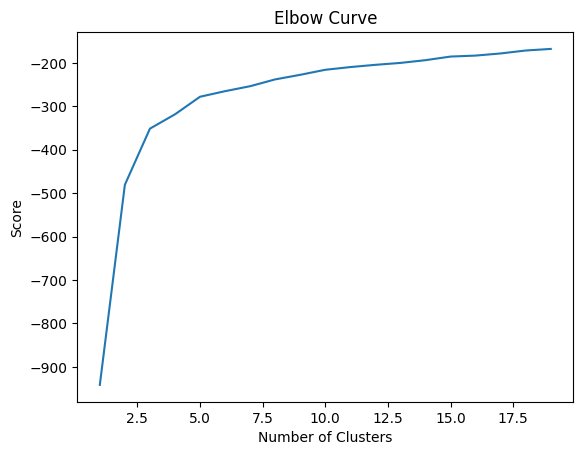

In [287]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [288]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
df.head()

,pct_duel_won,duels_per_minute,foul_committed_per_minute,yellow_cards_per_minute,red_cards_per_minute,pressures_applied_per_minute,blocks_per_minute,interceptions_per_minute,cluster
0,0.673077,0.034443,0.000000,0.001987,0.0,0.162612,0.019540,0.002981,0
1,0.571429,0.018007,0.000857,0.001715,0.0,0.265821,0.016292,0.000857,0
2,0.678161,0.024297,0.000000,0.000279,0.0,0.122042,0.018991,0.005865,0
3,0.644068,0.029157,0.000494,0.000988,0.0,0.157648,0.012849,0.003954,0
4,0.798165,0.021724,0.000399,0.000399,0.0,0.136126,0.013154,0.002990,1


In [289]:
len(df.columns)

9

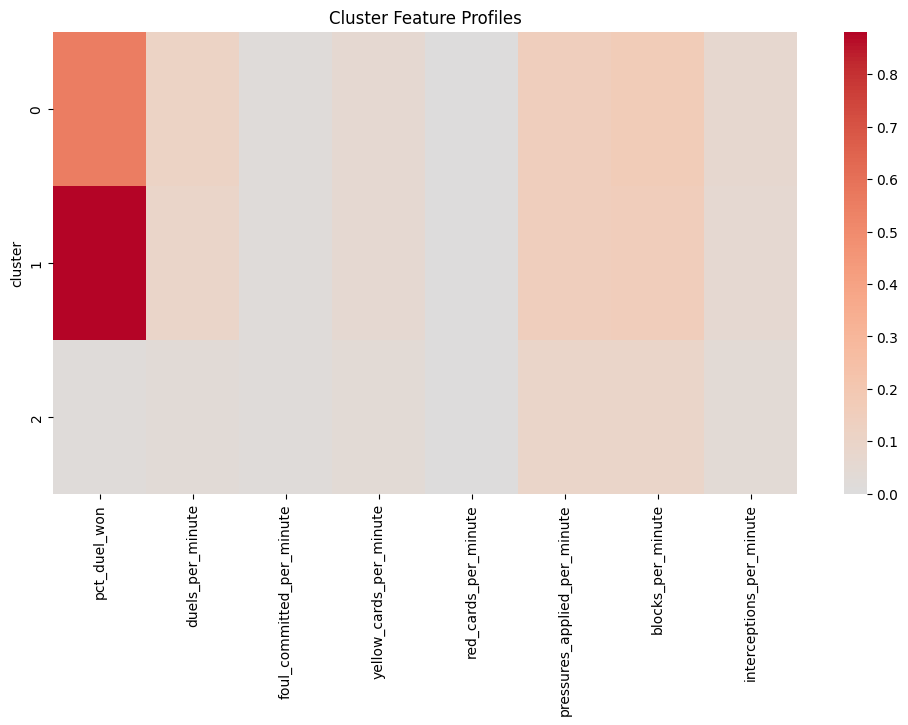

In [290]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

## Goal Keeper K-Means

In [291]:
df = pd.read_parquet(data_location/'gk_k_means.parquet')
print(df.head())

   gk_player_id  gk_shot_save_pct  gk_penalty_save_pct  pct_q1_shot_xg  \
0         26753          0.734375                  0.0        0.083333   
1         15709          0.765333                  0.0        0.128000   
2         22130          0.623077                  0.0        0.026923   
3          3970          0.840000                  0.0        0.146667   
4          5636          0.500000                  0.0        0.000000   

   pct_q2_shot_xg  pct_q3_shot_xg  pct_q4_shot_xg  gk_collected_per_minute  \
0        0.093750        0.130208        0.375000                 0.008954   
1        0.104000        0.122667        0.349333                 0.020154   
2        0.026923        0.188462        0.353846                 0.004612   
3        0.080000        0.160000        0.386667                 0.005763   
4        0.100000        0.100000        0.250000                 0.000000   

   gk_keeper_sweeper_per_minute  gk_smother_per_minute  gk_punch_per_minute  \
0      

In [292]:
df.isnull().sum()
print(len(df))

501


In [293]:
df.dropna(inplace=True)
print(len(df))

499


In [294]:
df = df.drop(columns=['gk_player_id'])

In [295]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,gk_shot_save_pct,gk_penalty_save_pct,pct_q1_shot_xg,pct_q2_shot_xg,pct_q3_shot_xg,pct_q4_shot_xg,gk_collected_per_minute,gk_keeper_sweeper_per_minute,gk_smother_per_minute,gk_punch_per_minute,gk_shot_faced_per_minute,gk_penalty_faced_per_minute,pct_shot_from_gk_right,pct_shot_from_gk_left,pct_shot_from_gk_unk
0,0.458984,0.0,0.166667,0.187500,0.260417,0.375000,0.172607,0.339151,0.105495,0.180179,0.296345,0.0,0.328125,0.484375,0.187500
1,0.478333,0.0,0.256000,0.208000,0.245333,0.349333,0.388525,0.254467,0.019788,0.080112,0.462627,0.0,0.384000,0.413333,0.202667
2,0.389423,0.0,0.053846,0.053846,0.376923,0.353846,0.088914,0.310585,0.326057,0.220004,0.223898,0.0,0.565385,0.242308,0.192308
3,0.525000,0.0,0.293333,0.160000,0.320000,0.386667,0.111097,0.031046,0.000000,0.096213,0.226520,0.0,0.400000,0.386667,0.213333
4,0.312500,0.0,0.000000,0.200000,0.200000,0.250000,0.000000,0.091837,0.321372,0.162632,0.392555,0.0,0.550000,0.300000,0.150000


In [296]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

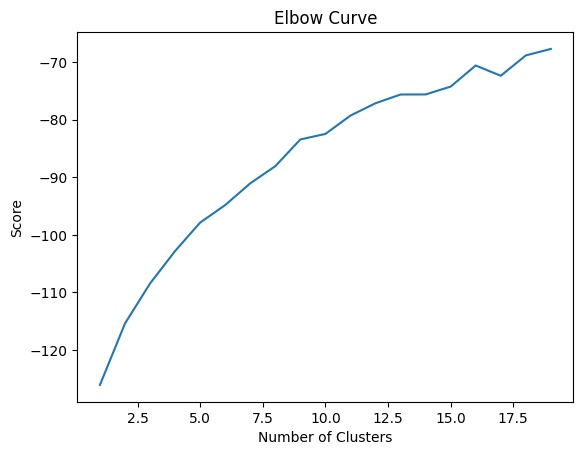

In [297]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [298]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
df.head()

,gk_shot_save_pct,gk_penalty_save_pct,pct_q1_shot_xg,pct_q2_shot_xg,pct_q3_shot_xg,pct_q4_shot_xg,gk_collected_per_minute,gk_keeper_sweeper_per_minute,gk_smother_per_minute,gk_punch_per_minute,gk_shot_faced_per_minute,gk_penalty_faced_per_minute,pct_shot_from_gk_right,pct_shot_from_gk_left,pct_shot_from_gk_unk,cluster
0,0.734375,0.0,0.083333,0.093750,0.130208,0.375000,0.008954,0.012591,0.001119,0.007555,0.053722,0.0,0.328125,0.484375,0.187500,3
1,0.765333,0.0,0.128000,0.104000,0.122667,0.349333,0.020154,0.009447,0.000210,0.003359,0.078727,0.0,0.384000,0.413333,0.202667,1
2,0.623077,0.0,0.026923,0.026923,0.188462,0.353846,0.004612,0.011531,0.003459,0.009224,0.042828,0.0,0.565385,0.242308,0.192308,1
3,0.840000,0.0,0.146667,0.080000,0.160000,0.386667,0.005763,0.001153,0.000000,0.004034,0.043222,0.0,0.400000,0.386667,0.213333,4
4,0.500000,0.0,0.000000,0.100000,0.100000,0.250000,0.000000,0.003409,0.003409,0.006819,0.068190,0.0,0.550000,0.300000,0.150000,1


In [299]:
len(df.columns)

16

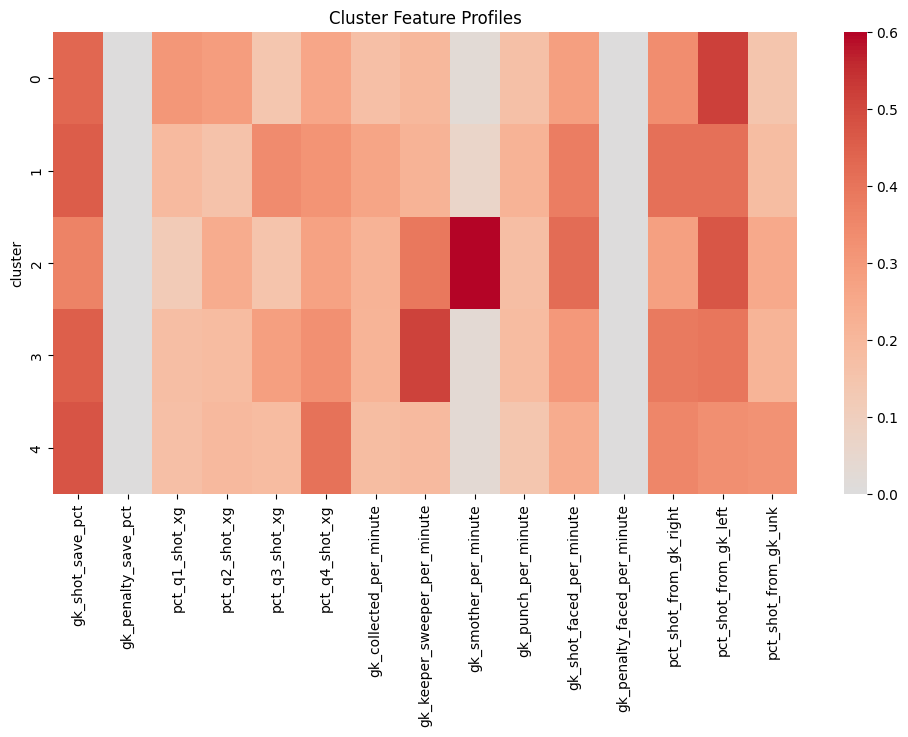

In [300]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

## Pass K-Means

In [301]:
df = pd.read_parquet(data_location/'pass_k_means.parquet')
print(df.head())

   player_id  MINUTES_ON_PITCH  pass_attempt  pass_success_pct  \
0       8517       3184.333333        1307.0          0.296098   
1      25863       1515.550000         866.0          0.176674   
2      19634        226.433333          91.0          0.065934   
3       5506      16429.483333       12222.0          0.069383   
4       3385       8347.366667        3814.0          0.215522   

   pass_attempts_per_minute  percent_cross_success  \
0                  0.410447               0.000000   
1                  0.571410               0.212121   
2                  0.401884               0.000000   
3                  0.743907               0.142857   
4                  0.456911               0.387283   

   percent_through_ball_success  percent_through_ball  percent_cross  \
0                      0.000000              0.000000       0.000000   
1                      0.250000              0.004619       0.038106   
2                      0.000000              0.010989       0.

In [302]:
df.isnull().sum()
print(len(df))

8981


In [303]:
df.dropna(inplace=True)
print(len(df))

7668


In [304]:
df = df.drop(columns=['player_id'])

In [305]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,MINUTES_ON_PITCH,pass_attempt,pass_success_pct,pass_attempts_per_minute,percent_cross_success,percent_through_ball_success,percent_through_ball,percent_cross,percent_q1,percent_q2,percent_q3,percent_q4,pass_shot_assist_per_minute
0,0.060360,0.038036,0.333110,0.154578,0.000000,0.000000,0.000000,0.000000,0.233359,0.463963,0.276533,0.219348,0.000000
1,0.027912,0.025192,0.198759,0.216554,0.212121,0.250000,0.023095,0.083834,0.177829,0.454503,0.229847,0.328666,0.043099
2,0.002846,0.002621,0.074176,0.151281,0.000000,0.000000,0.054945,0.000000,0.153846,0.404396,0.310832,0.305975,0.000000
3,0.317899,0.355924,0.078056,0.282971,0.142857,0.469388,0.020046,0.001260,0.132793,0.337359,0.304291,0.377332,0.018553
4,0.160750,0.111050,0.242462,0.172468,0.387283,0.508475,0.077347,0.099790,0.235186,0.376298,0.252978,0.297154,0.113030


In [306]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

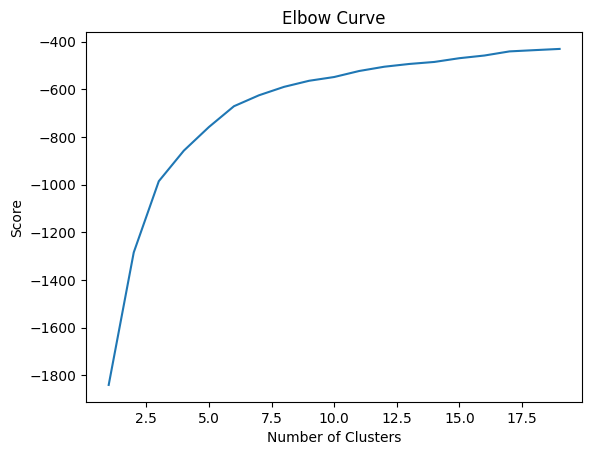

In [ ]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [ ]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
df.head()

,MINUTES_ON_PITCH,pass_attempt,pass_success_pct,pass_attempts_per_minute,percent_cross_success,percent_through_ball_success,percent_through_ball,percent_cross,percent_q1,percent_q2,percent_q3,percent_q4,pass_shot_assist_per_minute,cluster
0,3184.333333,1307.0,0.296098,0.410447,0.000000,0.000000,0.000000,0.000000,0.233359,0.289977,0.263963,0.212701,0.000000,0
1,1515.550000,866.0,0.176674,0.571410,0.212121,0.250000,0.004619,0.038106,0.177829,0.284065,0.219400,0.318707,0.005938,2
2,226.433333,91.0,0.065934,0.401884,0.000000,0.000000,0.010989,0.000000,0.153846,0.252747,0.296703,0.296703,0.000000,0
3,16429.483333,12222.0,0.069383,0.743907,0.142857,0.469388,0.004009,0.000573,0.132793,0.210849,0.290460,0.365898,0.002556,2
4,8347.366667,3814.0,0.215522,0.456911,0.387283,0.508475,0.015469,0.045359,0.235186,0.235186,0.241479,0.288149,0.015574,2


In [ ]:
len(df.columns)

14

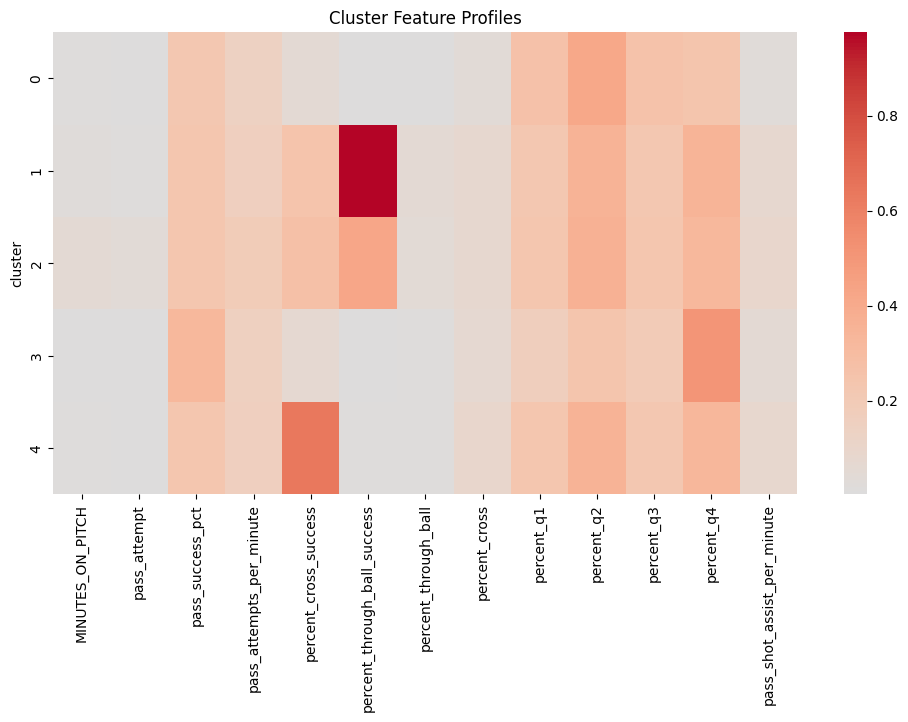

In [ ]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()

## Shot K-Means

In [ ]:
df = pd.read_parquet(data_location/'shot_k_means.parquet')
print(df.head())

   player_id  pct_shot_first_time  pct_shot_follows_dribble  \
0      26101             0.200000                       0.0   
1      40486             0.428571                       0.0   
2      19757             0.252427                       0.0   
3       3629             0.273504                       0.0   
4       3616             0.210526                       0.0   

   pct_shot_open_goal  pct_shot_dominant_foot  pct_shot_header  \
0            0.000000                0.800000         0.000000   
1            0.035714                0.607143         0.178571   
2            0.009709                0.864078         0.019417   
3            0.025641                0.529915         0.059829   
4            0.000000                0.736842         0.052632   

   pct_shot_into_goal  pct_shot_saved  shots_per_minute  goals_over_expected  \
0            0.000000        0.000000          0.054536            -0.299891   
1            0.035714        0.000000          0.024415         

In [ ]:
df.isnull().sum()
print(len(df))

6144


In [ ]:
df.dropna(inplace=True)
print(len(df))

5477


In [ ]:
df = df.drop(columns=['player_id'])

In [ ]:
minmax_processed = preprocessing.MinMaxScaler().fit_transform(df)
df_numeric_scaled = pd.DataFrame(minmax_processed, index=df.index, columns=df.columns)
df_numeric_scaled.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_into_goal,pct_shot_saved,shots_per_minute,goals_over_expected,pct_shot_q1,pct_shot_q2,pct_shot_q3,pct_shot_q4,pct_shots_taken_in_arc,pct_of_goals_from_arc,pct_shots_taken_in_box,pct_of_goals_from_box
0,0.200000,0.0,0.000000,0.800000,0.000000,0.000000,0.000000,0.251069,0.051628,0.200000,0.000000,0.800000,0.000000,0.400000,0.000000,0.600000,0.000000
1,0.428571,0.0,0.035714,0.607143,0.178571,0.035714,0.000000,0.093512,0.039793,0.142857,0.285714,0.285714,0.285714,0.428571,0.000000,0.553571,1.000000
2,0.252427,0.0,0.009709,0.864078,0.019417,0.067961,0.009709,0.089699,0.060456,0.058252,0.135922,0.330097,0.475728,0.747573,0.714286,0.252427,0.285714
3,0.273504,0.0,0.025641,0.529915,0.059829,0.136752,0.000000,0.160607,0.049096,0.213675,0.418803,0.264957,0.102564,0.333333,0.125000,0.658120,0.875000
4,0.210526,0.0,0.000000,0.736842,0.052632,0.315789,0.000000,0.093796,0.065081,0.315789,0.473684,0.157895,0.052632,0.210526,0.000000,0.736842,1.000000


In [ ]:
Nc = range(1, 20)

kmeans = [KMeans(n_clusters=i) for i in Nc]

score = [kmeans[i].fit(df_numeric_scaled).score(df_numeric_scaled) for i in range(len(kmeans))]

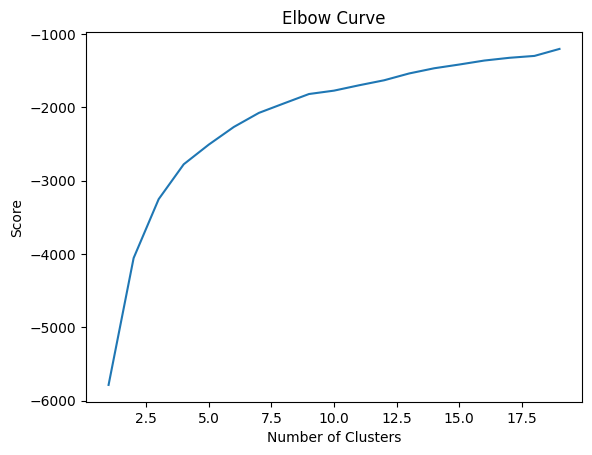

In [ ]:
pl.plot(Nc,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

In [ ]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_numeric_scaled)
df['cluster'] = kmeans.labels_
df.head()

,pct_shot_first_time,pct_shot_follows_dribble,pct_shot_open_goal,pct_shot_dominant_foot,pct_shot_header,pct_shot_into_goal,pct_shot_saved,shots_per_minute,goals_over_expected,pct_shot_q1,pct_shot_q2,pct_shot_q3,pct_shot_q4,pct_shots_taken_in_arc,pct_of_goals_from_arc,pct_shots_taken_in_box,pct_of_goals_from_box,cluster
0,0.200000,0.0,0.000000,0.800000,0.000000,0.000000,0.000000,0.054536,-0.299891,0.200000,0.000000,0.800000,0.000000,0.400000,0.000000,0.600000,0.000000,1
1,0.428571,0.0,0.035714,0.607143,0.178571,0.035714,0.000000,0.024415,-2.262913,0.142857,0.285714,0.285714,0.285714,0.428571,0.000000,0.553571,1.000000,2
2,0.252427,0.0,0.009709,0.864078,0.019417,0.067961,0.009709,0.023686,1.164438,0.058252,0.135922,0.330097,0.475728,0.747573,0.714286,0.252427,0.285714,1
3,0.273504,0.0,0.025641,0.529915,0.059829,0.136752,0.000000,0.037241,-0.719881,0.213675,0.418803,0.264957,0.102564,0.333333,0.125000,0.658120,0.875000,2
4,0.210526,0.0,0.000000,0.736842,0.052632,0.315789,0.000000,0.024469,1.931559,0.315789,0.473684,0.157895,0.052632,0.210526,0.000000,0.736842,1.000000,2


In [ ]:
len(df.columns)

18

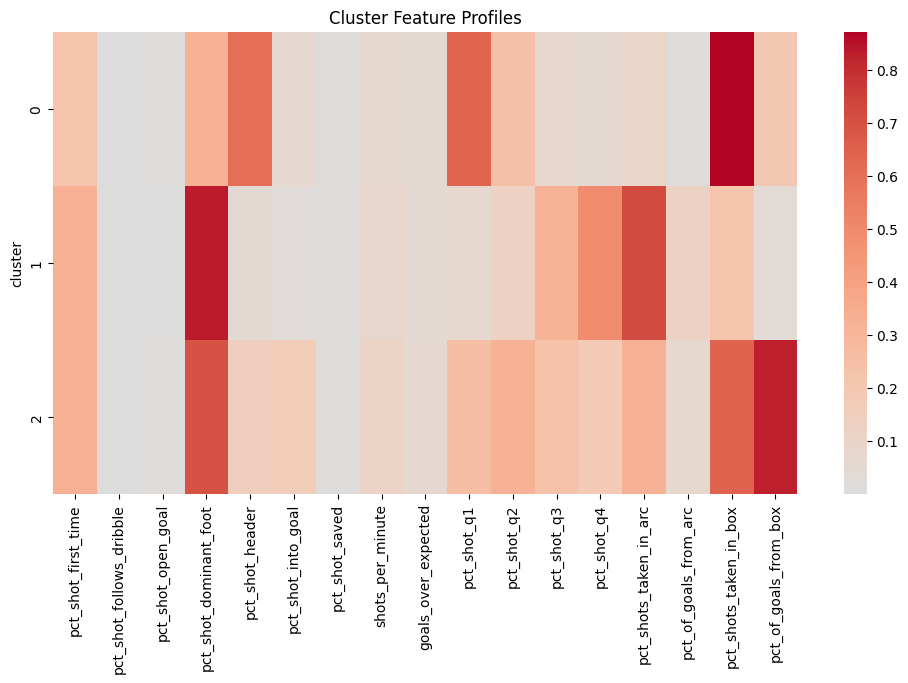

In [ ]:
#collaborated with genAI to create heatmap code
cluster_means = df_numeric_scaled.copy()
cluster_means['cluster'] = df['cluster']
cluster_means = cluster_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="coolwarm", center=0)
plt.title("Cluster Feature Profiles")
plt.show()